In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import warnings
import nbformat
import plotly.graph_objects as go
warnings.filterwarnings('ignore')

# Load feature store data
df = pd.read_parquet('../data/features.parquet')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
df.head()

Dataset shape: (2184, 16)
Date range: 2026-03-06 00:00:00 to 2026-06-04 23:00:00


,city,timestamp,hour,day,month,day_of_week,aqi,pm2_5,pm10,no2,ozone,temperature,humidity,wind_speed,precipitation,surface_pressure
0,karachi,2026-03-06 00:00:00,0,6,3,4,59.0,17.4,29.9,5.6,65.0,22.5,90.0,14.9,0.0,1009.7
1,karachi,2026-03-06 01:00:00,1,6,3,4,60.0,18.1,30.3,9.6,60.0,22.7,90.0,14.4,0.0,1009.9
2,karachi,2026-03-06 02:00:00,2,6,3,4,60.0,19.7,31.7,14.9,54.0,22.5,92.0,13.3,0.0,1010.3
3,karachi,2026-03-06 03:00:00,3,6,3,4,61.0,22.2,37.1,17.7,53.0,23.4,86.0,14.1,0.0,1011.0
4,karachi,2026-03-06 04:00:00,4,6,3,4,62.0,21.7,46.8,15.5,63.0,25.0,76.0,14.5,0.0,1011.5


## 🌫️ AQI Category Distribution Analysis

Air Quality Index (AQI) values are grouped into categories that represent the potential health impact on people.

This visualization helps us understand how often Karachi experiences clean air versus polluted air conditions.

Higher frequencies of "Unhealthy" and "Very Unhealthy" categories indicate increased environmental and public health risks.


In [17]:
print("=== Dataset Info ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Basic Statistics ===")
df.describe()

=== Dataset Info ===
city                        object
timestamp           datetime64[ns]
hour                         int64
day                          int64
month                        int64
day_of_week                  int64
aqi                        Float64
pm2_5                      Float64
pm10                       Float64
no2                        Float64
ozone                      Float64
temperature                Float64
humidity                   Float64
wind_speed                 Float64
precipitation              Float64
surface_pressure           Float64
aqi_category                object
dtype: object

=== Missing Values ===
city                0
timestamp           0
hour                0
day                 0
month               0
day_of_week         0
aqi                 0
pm2_5               0
pm10                0
no2                 0
ozone               0
temperature         0
humidity            0
wind_speed          0
precipitation       0
surface_pressure

,timestamp,hour,day,month,day_of_week,aqi,pm2_5,pm10,no2,ozone,temperature,humidity,wind_speed,precipitation,surface_pressure
count,2184,2184.000000,2184.000000,2184.000000,2184.000000,2184.0,2184.0,2184.0,2184.0,2184.0,2184.0,2184.0,2184.0,2184.0,2184.0
mean,2026-04-20 11:30:00.000000256,11.500000,15.956044,4.142857,3.000000,79.731685,25.041163,59.490614,15.007005,79.22619,28.036951,70.730311,11.432051,0.013233,1006.741804
min,2026-03-06 00:00:00,0.000000,1.000000,3.000000,0.000000,32.0,3.5,3.7,2.0,11.0,17.7,7.0,0.5,0.0,998.3
25%,2026-03-28 17:45:00,5.750000,8.000000,3.000000,1.000000,67.0,18.0,34.575,6.4,52.0,25.4,60.0,8.4,0.0,1004.2
50%,2026-04-20 11:30:00,11.500000,16.000000,4.000000,3.000000,74.0,22.9,48.8,11.8,73.0,28.2,72.0,11.45,0.0,1006.8
75%,2026-05-13 05:15:00,17.250000,24.000000,5.000000,5.000000,90.0,30.3,72.25,20.1,102.0,30.4,84.0,14.3,0.0,1009.3
max,2026-06-04 23:00:00,23.000000,31.000000,6.000000,6.000000,161.0,75.0,504.8,70.1,203.0,41.2,99.0,23.4,7.8,1015.6
std,NaN,6.923772,8.831185,0.884391,2.000458,19.822723,10.036299,38.711578,11.119663,34.792193,3.429197,16.995326,4.100476,0.220863,3.501249


## ⏰ Hourly AQI Behavior

Air pollution levels can vary significantly throughout the day due to:

* traffic congestion
* industrial activity
* weather conditions
* human movement patterns

This analysis identifies the hours during which Karachi experiences the highest pollution levels.


In [27]:
hourly_aqi = (
    df.groupby("hour")["aqi"]
    .mean()
    .reset_index()
)

fig = px.line(
    hourly_aqi,
    x="hour",
    y="aqi",
    markers=True,
    title="Average AQI by Hour of Day"
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

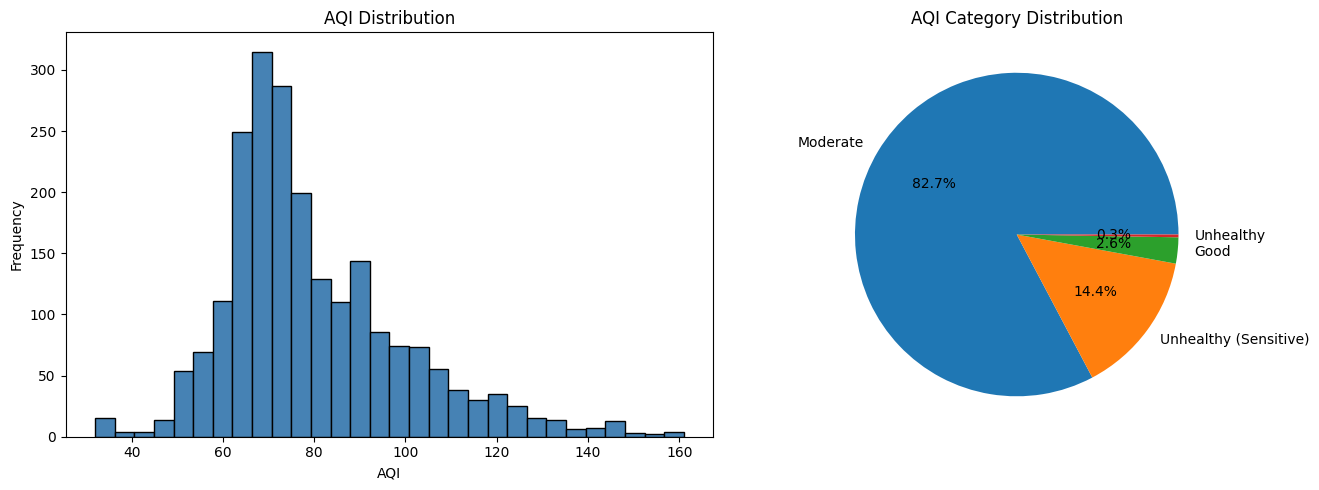

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['aqi'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('AQI Distribution')
axes[0].set_xlabel('AQI')
axes[0].set_ylabel('Frequency')

# AQI Categories
def categorize_aqi(aqi):
    if aqi <= 50: return 'Good'
    elif aqi <= 100: return 'Moderate'
    elif aqi <= 150: return 'Unhealthy (Sensitive)'
    elif aqi <= 200: return 'Unhealthy'
    elif aqi <= 300: return 'Very Unhealthy'
    else: return 'Hazardous'

df['aqi_category'] = df['aqi'].apply(categorize_aqi)
category_counts = df['aqi_category'].value_counts()
axes[1].pie(category_counts, labels=category_counts.index, autopct='%1.1f%%')
axes[1].set_title('AQI Category Distribution')

plt.tight_layout()
plt.savefig('../notebooks/aqi_distribution.png', dpi=100)
plt.show()

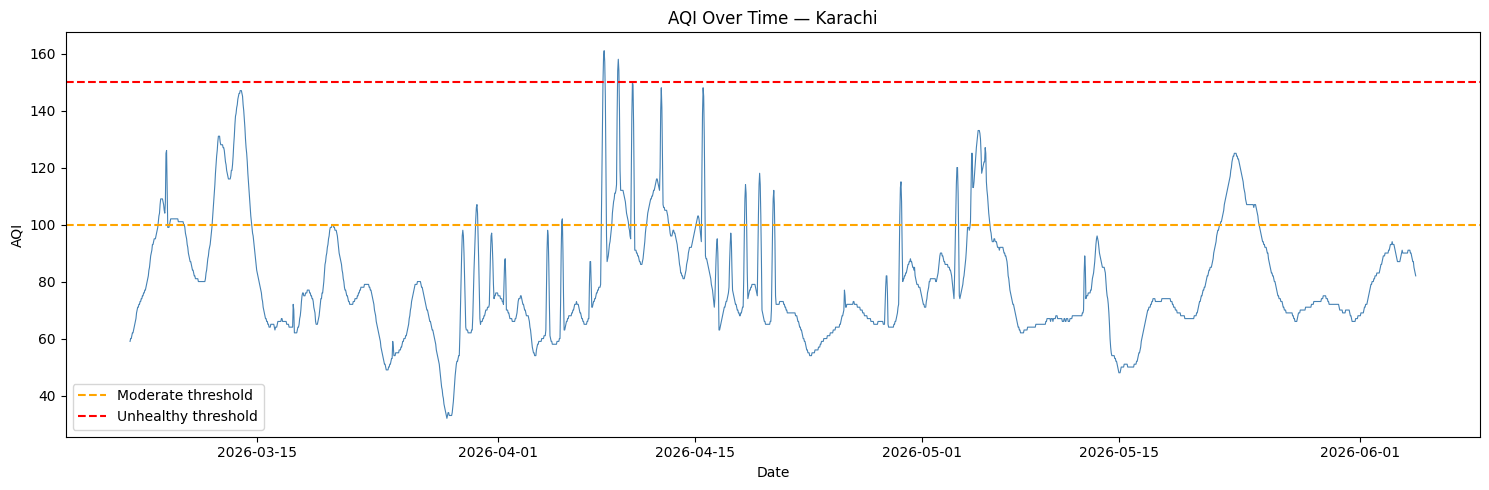

In [19]:
plt.figure(figsize=(15, 5))
plt.plot(df['timestamp'], df['aqi'], color='steelblue', linewidth=0.8)
plt.axhline(y=100, color='orange', linestyle='--', label='Moderate threshold')
plt.axhline(y=150, color='red', linestyle='--', label='Unhealthy threshold')
plt.title('AQI Over Time — Karachi')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/aqi_over_time.png', dpi=100)
plt.show()

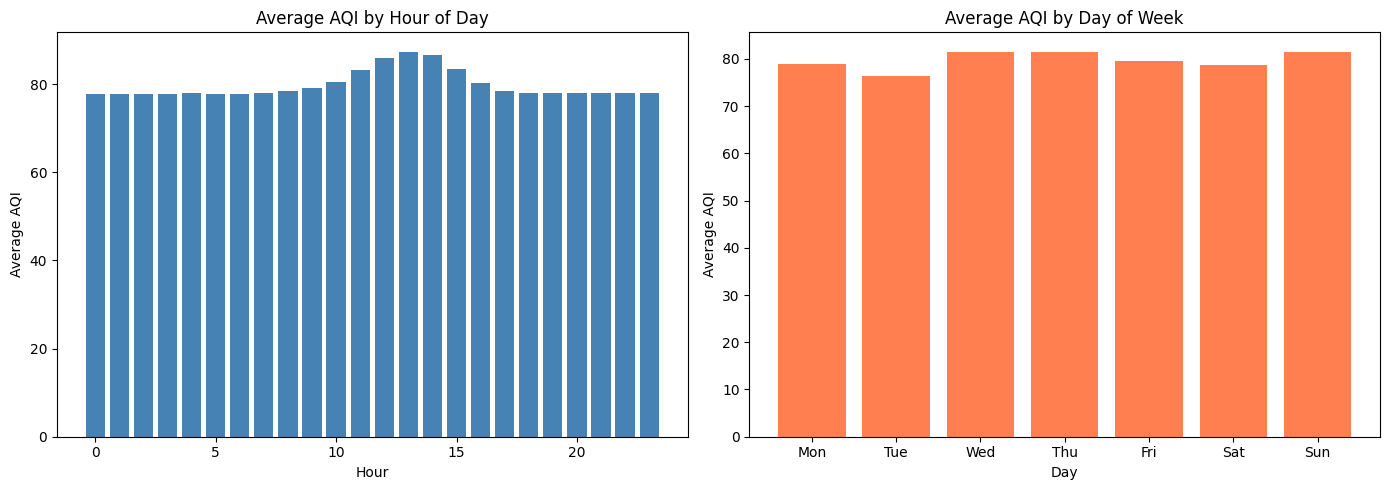

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AQI by hour
hourly_avg = df.groupby('hour')['aqi'].mean()
axes[0].bar(hourly_avg.index, hourly_avg.values, color='steelblue')
axes[0].set_title('Average AQI by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Average AQI')

# AQI by day of week
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_avg = df.groupby('day_of_week')['aqi'].mean()
axes[1].bar(days, daily_avg.values, color='coral')
axes[1].set_title('Average AQI by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Average AQI')

plt.tight_layout()
plt.savefig('../notebooks/aqi_patterns.png', dpi=100)
plt.show()

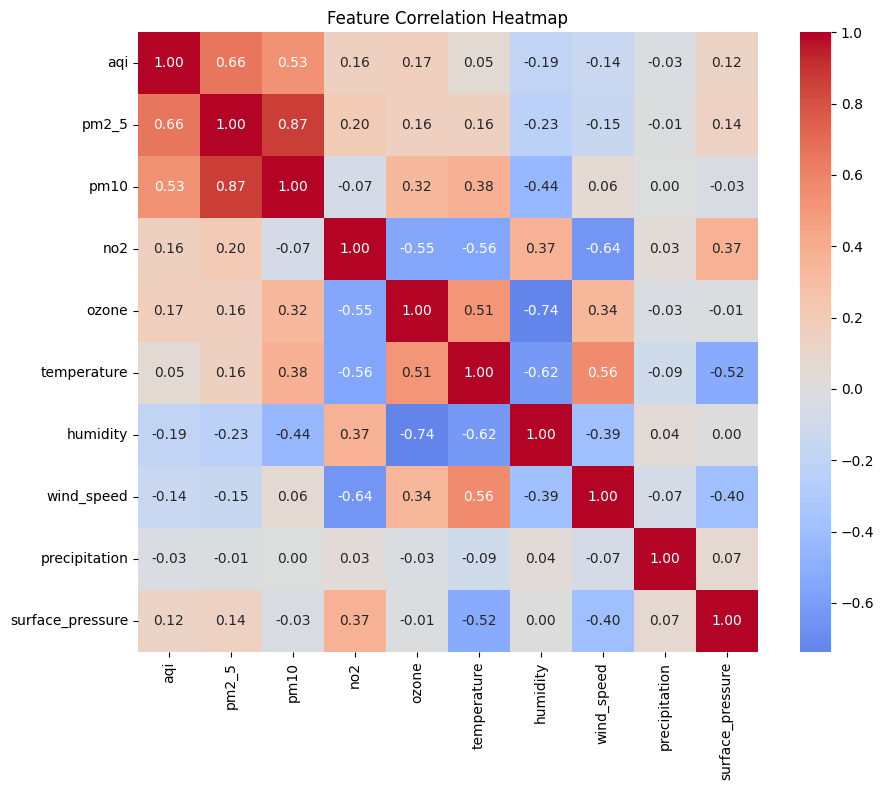

In [21]:
numeric_cols = ['aqi', 'pm2_5', 'pm10', 'no2', 'ozone',
                'temperature', 'humidity', 'wind_speed',
                'precipitation', 'surface_pressure']

plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../notebooks/correlation_heatmap.png', dpi=100)
plt.show()

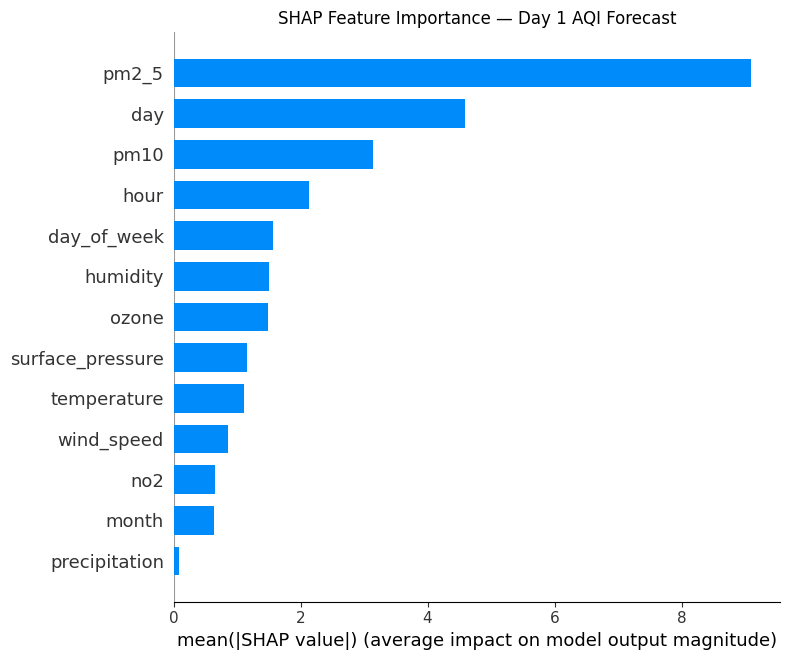

In [22]:
import shap
import joblib
from xgboost import XGBRegressor

# Load best model (Day 1 - XGBoost)
model = joblib.load('../tmp/models/day1/model.pkl')

# Prepare features
feature_cols = ['hour', 'day', 'month', 'day_of_week',
                'temperature', 'humidity', 'wind_speed',
                'precipitation', 'surface_pressure',
                'pm2_5', 'pm10', 'no2', 'ozone']

X = df[feature_cols].dropna().astype(float)

# SHAP explanation
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X[:500])

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X[:500], plot_type='bar', show=False)
plt.title('SHAP Feature Importance — Day 1 AQI Forecast')
plt.tight_layout()
plt.savefig('../notebooks/shap_importance.png', dpi=100)
plt.show()

=== Model Performance Summary ===

Day 1 Forecast:
  Best Model : XGBoost
  RMSE       : 7.54
  MAE        : 5.13
  R²         : 0.8506

Day 2 Forecast:
  Best Model : RandomForest
  RMSE       : 6.58
  MAE        : 4.33
  R²         : 0.8966

Day 3 Forecast:
  Best Model : XGBoost
  RMSE       : 5.62
  MAE        : 3.77
  R²         : 0.9194



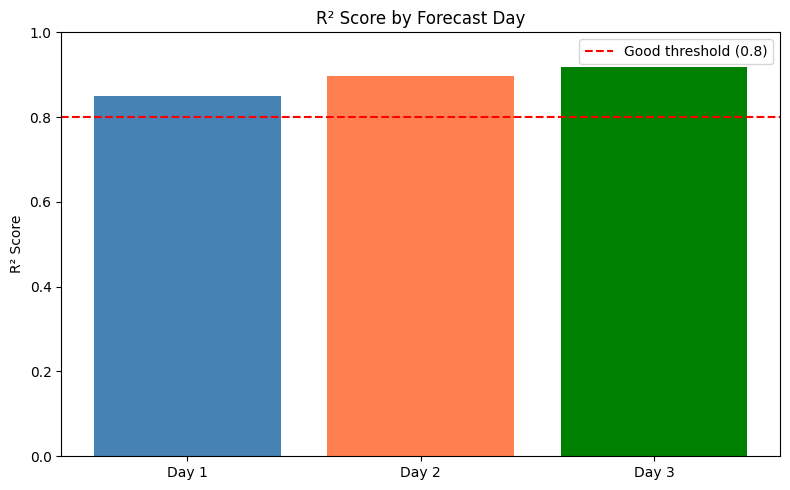

In [23]:
print("=== Model Performance Summary ===\n")
results = {
    'Day 1': {'model': 'XGBoost', 'rmse': 7.54, 'mae': 5.13, 'r2': 0.8506},
    'Day 2': {'model': 'RandomForest', 'rmse': 6.58, 'mae': 4.33, 'r2': 0.8966},
    'Day 3': {'model': 'XGBoost', 'rmse': 5.62, 'mae': 3.77, 'r2': 0.9194},
}

for day, metrics in results.items():
    print(f"{day} Forecast:")
    print(f"  Best Model : {metrics['model']}")
    print(f"  RMSE       : {metrics['rmse']}")
    print(f"  MAE        : {metrics['mae']}")
    print(f"  R²         : {metrics['r2']}")
    print()

# Bar chart
days = list(results.keys())
r2_scores = [results[d]['r2'] for d in days]

plt.figure(figsize=(8, 5))
plt.bar(days, r2_scores, color=['steelblue', 'coral', 'green'])
plt.ylim(0, 1)
plt.axhline(y=0.8, color='red', linestyle='--', label='Good threshold (0.8)')
plt.title('R² Score by Forecast Day')
plt.ylabel('R² Score')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/model_performance.png', dpi=100)
plt.show()